In [1]:
# Step 1: Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [2]:
# Step 2: Load dataset
# Specify the path to your dataset (update 'your_data.csv' with your actual file path)
data_path = 'FOS.csv'  # Replace with your file path or upload in Jupyter
data = pd.read_csv(data_path)

In [3]:
# Step 3: Preprocess the data
# Replace 'target_column' with the actual name of the target column in your dataset
target_column = 'FOS'  # Update this
X = data.drop(target_column, axis=1)  # Features
y = data[target_column]  # Target

In [4]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200)

In [5]:
# Step 5: Build the Artificial Neural Network model
model = Sequential()

In [6]:
# Input layer (based on the number of features)
model.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))

C:\Users\majid\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Hidden layers
model.add(Dense(units=32, activation='relu'))  # First hidden layer
model.add(Dense(units=16, activation='relu'))  # Second hidden layer

In [8]:
# Output layer (for regression, single neuron with no activation function)
model.add(Dense(units=1, activation='linear'))

In [9]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

In [11]:
# Step 6: Train the model
history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/500
479/479 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 2/500
479/479 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 3/500
479/479 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 4/500
479/479 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 5/500
479/479 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 6/500
479/479 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 7/500
479/479 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0015 - val_loss: 0.0043
Epoch 8/500
479/479 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0029 - val_loss: 0.0013
Epoch 9/500
479/479 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0015 - val_loss: 0.0037
Epoch 10/500
479/479 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 11/500
479/479 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 12/500
479/479 ━━━━━━━━━━━━━━━━━━━━

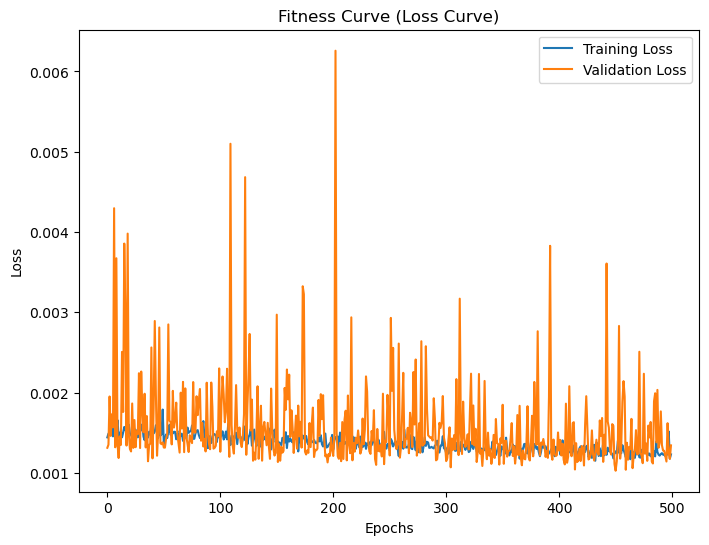

In [12]:
# Step 7: Plot the fitness (loss) curve
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Fitness Curve (Loss Curve)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
# Step 8: Make predictions
y_pred = model.predict(X_test)

120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [14]:
# Step 9: Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"R²: {r2:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

R²: 0.998
Mean Absolute Error (MAE): 0.024
Root Mean Squared Error (RMSE): 0.037


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [15]:
# Step 10: Save predictions for test data to Excel
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.flatten()})
predictions_df.to_excel('ann_predictions_test.xlsx', index=False)  # Save to Excel file
print("Predictions for test data saved to 'ann_predictions_test.xlsx'")

Predictions for test data saved to 'ann_predictions_test.xlsx'


In [16]:
# Step 11: Save predictions for all data points to Excel
y_pred_all = model.predict(X)  # Predict for all rows in the dataset (training + test)
data['Predicted'] = y_pred_all.flatten()  # Add predictions to the original data

598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step


In [17]:
# Save the full dataset with predictions to Excel
data.to_excel('ann_predictions_all_data.xlsx', index=False)  # Save to Excel file
print("Predictions for all data points saved to 'ann_predictions_all_data.xlsx'")

Predictions for all data points saved to 'ann_predictions_all_data.xlsx'


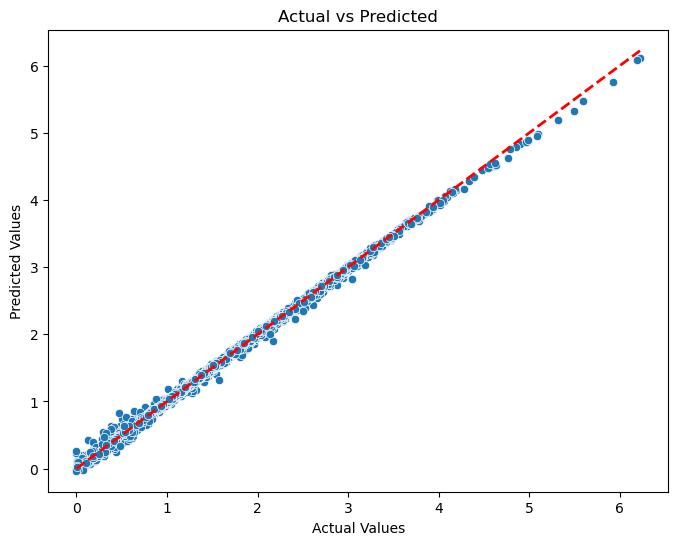

In [18]:
# Step 12: Visualization of predictions vs actual values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred.flatten())  # Flatten to make it 1D
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

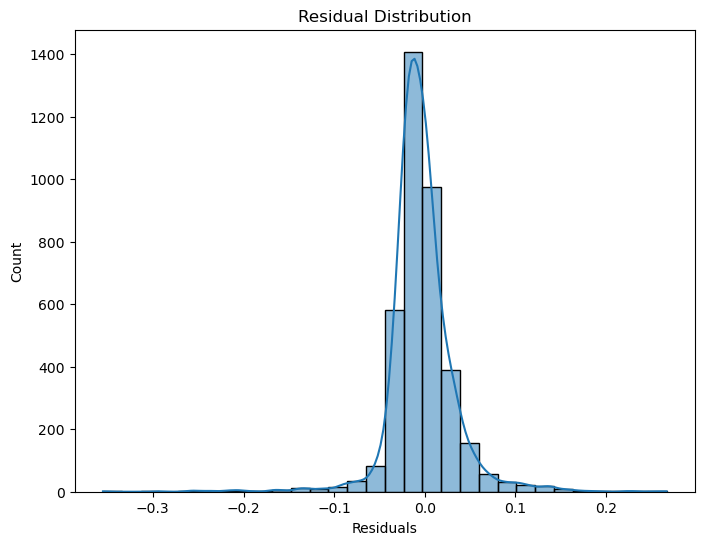

In [19]:
# Residual Plot
residuals = y_test - y_pred.flatten()  # Flatten to match the shape
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel('Residuals')
plt.title('Residual Distribution')
plt.show()